# Cell-type specificity comparison: Locat vs GSPA vs LMD vs Hotspot vs Haystack

3k PBMC dataset. Each method ranks genes without using cell-type labels. We evaluate how well each ranking recovers cell-type-specific genes using a rolling mean of a per-gene specificity score computed from louvain labels.

In [1]:
!nvidia-smi

Mon Jun  1 07:45:19 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    Off  | 00000000:01:00.0 Off |                  Off |
| 30%   24C    P8     9W / 300W |   3468MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    Off  | 00000000:24:00.0 Off |                  Off |
| 30%   

|   5  NVIDIA RTX A6000    Off  | 00000000:A1:00.0 Off |                  Off |
| 30%   29C    P8    20W / 300W |   4890MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   6  NVIDIA RTX A6000    Off  | 00000000:C1:00.0 Off |                  Off |
| 30%   24C    P8    10W / 300W |   3668MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   7  NVIDIA RTX A6000    Off  | 00000000:E1:00.0 Off |                  Off |
| 30%   23C    P8     5W / 300W |   1224MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                        

|    2   N/A  N/A   2686178      C   /usr/local/bin/python            1222MiB |
|    2   N/A  N/A   2688027      C   /usr/local/bin/python            1222MiB |
|    2   N/A  N/A   2689785      C   /usr/local/bin/python            1222MiB |
|    3   N/A  N/A   2589420      C   /usr/local/bin/python            2196MiB |
|    3   N/A  N/A   2695809      C   /usr/local/bin/python            1222MiB |
|    3   N/A  N/A   2770757      C   /usr/local/bin/python            1222MiB |
|    3   N/A  N/A   3383236      C   /usr/local/bin/python            1222MiB |
|    3   N/A  N/A   3387268      C   /usr/local/bin/python            1222MiB |
|    4   N/A  N/A   2433001      C   /usr/local/bin/python            1222MiB |
|    4   N/A  N/A   2443731      C   /usr/local/bin/python            1222MiB |
|    4   N/A  N/A   2589584      C   /usr/local/bin/python            2094MiB |
|    4   N/A  N/A   2783340      C   /usr/local/bin/python            1222MiB |
|    4   N/A  N/A   3547323      C   /us

|    6   N/A  N/A   2589822      C   /usr/local/bin/python            1222MiB |
|    6   N/A  N/A   3999331      C   /usr/local/bin/python            1222MiB |
|    6   N/A  N/A   4058570      C   /usr/local/bin/python            1222MiB |
|    7   N/A  N/A   2688027      C   /usr/local/bin/python            1222MiB |
+-----------------------------------------------------------------------------+


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [3]:
from __future__ import annotations
import os, sys, random, subprocess, re
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

LOCAT_SRC = Path("/banach2/wes/locat-0.1")
# 9543-gene dataset: raw-from-processed, log1p, min_cells=20, <90% expressed (AUC benchmark filter)
DATA_PATH  = Path("/banach2/wes/Locat-paper-repro-private/data/pbmc3k_9543_lognorm.h5ad")
OUT_DIR    = Path(".")

if str(LOCAT_SRC) not in sys.path:
    sys.path.insert(0, str(LOCAT_SRC))

from locat.locat import LOCAT
import locat, locat.locat as locat_impl

SEED = 13

def reset_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

reset_seeds()
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, facecolor="white")
sns.set_context("talk")

print(f"locat version: {getattr(locat, '__version__', 'unknown')}")
assert DATA_PATH.exists(), DATA_PATH

locat version: 0.1.6.dev1+g2ffb1e289


## Load data

In [4]:
reset_seeds()
# All methods use the same 9543-gene log1p-normalized dataset.
# PCA/UMAP embeddings are from the processed adata and stored in the file.
adata = sc.read_h5ad(DATA_PATH)
print(adata)
print("Cell types:", adata.obs['louvain'].value_counts().to_dict())

AnnData object with n_obs × n_vars = 2638 × 9543
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_draw_graph_fr', 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'
Cell types: {'CD4 T cells': 1144, 'CD14+ Monocytes': 480, 'B cells': 342, 'CD8 T cells': 316, 'NK cells': 154, 'FCGR3A+ Monocytes': 150, 'Dendritic cells': 37, 'Megakaryocytes': 15}


## Per-gene cell-type specificity score (gold standard)

For each gene we compute:

$$\\tau_g = \\frac{\\max_c \\bar{x}_{g,c}}{\\sum_c \\bar{x}_{g,c}}$$

where $\\bar{x}_{g,c}$ is mean log-normalized expression of gene $g$ in cell type $c$. This ranges from $1/K$ (uniform across $K$ cell types) to $1$ (entirely restricted to one type). We exclude genes with no detectable expression.

In [5]:
cell_types = adata.obs['louvain'].cat.categories.tolist()
K = len(cell_types)
print(f"{K} cell types: {cell_types}")

X = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)  # cells x genes
genes_all = np.array(adata.var_names)

# mean expression per cell type
mean_per_ct = np.zeros((K, X.shape[1]))
for i, ct in enumerate(cell_types):
    mask = adata.obs['louvain'] == ct
    mean_per_ct[i] = X[mask].mean(axis=0)

row_sums = mean_per_ct.sum(axis=0)
# exclude genes with zero total expression across all cell types
expressed = row_sums > 0
tau = np.full(len(genes_all), np.nan)
tau[expressed] = mean_per_ct[:, expressed].max(axis=0) / row_sums[expressed]

specificity = pd.Series(tau, index=genes_all, name="tau_specificity")
print(f"Genes with specificity score: {expressed.sum()} / {len(genes_all)}")
print(f"Tau distribution (expressed genes):\n{specificity.dropna().describe()}")

8 cell types: ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']
Genes with specificity score: 9543 / 9543
Tau distribution (expressed genes):
count    9543.000000
mean        0.320982
std         0.122884
min         0.142598
25%         0.236458
50%         0.287538
75%         0.370058
max         0.976737
Name: tau_specificity, dtype: float64


## Run LOCAT

In [6]:
LOCAT_RESULTS_PATH = OUT_DIR / "locat_scores.npz"

if LOCAT_RESULTS_PATH.exists():
    print("Loading cached LOCAT results...")
    d = np.load(LOCAT_RESULTS_PATH, allow_pickle=True)
    locat_df = pd.DataFrame({
        "pval": d["pval"],
        "concentration_pval": d["concentration_pval"],
        "depletion_pval": d["depletion_pval"],
        "zscore": d["zscore"],
    }, index=d["gene_names"])
    print(f"Loaded {len(locat_df)} genes")
else:
    reset_seeds()
    embedding = adata.obsm["X_pca"].astype(np.float64)[:, :8]
    w_transform = lambda x: np.clip(np.asarray(x), 0.0, np.inf)
    
    model = LOCAT(
        adata=adata,
        cell_embedding=embedding,
        k=20,
        n_bootstrap_inits=50,
        show_progress=True,
        knn=adata.obsp["connectivities"],
        knn_mode="connectivity",
    )
    model._reg_covar = 1e-6
    
    results = model.gmm_scan(
        weights_transform=w_transform,
        max_freq=0.9,
        include_depletion_scan=True,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
    )
    
    rows = []
    for gene, res in results.items():
        d = res._asdict()
        rows.append({
            "gene": gene,
            "pval": d["pval"],
            "concentration_pval": d["concentration_pval"],
            "depletion_pval": d["depletion_pval"],
            "zscore": d["zscore"],
        })
    locat_df = pd.DataFrame(rows).set_index("gene")
    locat_df = locat_df.sort_values("pval")
    
    np.savez(
        LOCAT_RESULTS_PATH,
        gene_names=locat_df.index.values,
        pval=locat_df["pval"].values,
        concentration_pval=locat_df["concentration_pval"].values,
        depletion_pval=locat_df["depletion_pval"].values,
        zscore=locat_df["zscore"].values,
    )
    print(f"LOCAT done: {len(locat_df)} genes scored, saved to {LOCAT_RESULTS_PATH}")

display(locat_df.head(10))

Loading cached LOCAT results...
Loaded 9543 genes


,pval,concentration_pval,depletion_pval,zscore
CYP27A1,0.001408,0.000865,1.000000e-12,3.132933
BACE2,0.001449,0.000866,1.000000e-12,3.132829
STAB1,0.001538,0.004448,1.000000e-12,2.616049
RP11-428G5.5,0.001538,0.001495,1.000000e-12,2.968766
OSBPL10,0.001587,0.003469,1.000000e-12,2.699831
NOG,0.001639,0.003213,1.203884e-10,2.725232
FAR2,0.001639,0.002089,8.338179e-10,2.864339
COBLL1,0.001754,0.003004,1.000000e-12,2.747303
C2,0.001887,0.002900,1.000000e-12,2.758871
PAWR,0.001961,0.004290,1.000000e-12,2.628347


## Run GSPA (via gspa-env subprocess)

In [7]:
GSPA_RESULTS_PATH = OUT_DIR / "gspa_scores.npz"
GSPA_SCRIPT = Path(__file__).parent / "run_gspa.py" if "__file__" in dir() else Path("run_gspa.py")

if GSPA_RESULTS_PATH.exists():
    print("Loading cached GSPA results...")
else:
    print("Running GSPA in gspa-env subprocess...")
    result = subprocess.run(
        ["/banach2/wes/.conda/envs/gspa-env/bin/python", str(GSPA_SCRIPT)],
        capture_output=False,
        text=True,
        env={**os.environ, "CUDA_VISIBLE_DEVICES": "2"},
    )
    if result.returncode != 0:
        raise RuntimeError(f"GSPA subprocess failed (rc={result.returncode})")
    print("GSPA subprocess complete")

d = np.load(GSPA_RESULTS_PATH, allow_pickle=True)
gspa_scores = pd.Series(
    d["gene_localization"],
    index=d["var_names"],
    name="gspa_localization"
)
# GSPA: higher localization score = more localized (per DermalC paper code: rank(ascending=False))
print(f"GSPA loaded: {len(gspa_scores)} genes")
print(gspa_scores.sort_values(ascending=False).head(10))

Loading cached GSPA results...
GSPA loaded: 9543 genes
GZMK      6.178492
CCL5      5.958190
GZMH      5.502064
FCGR3A    5.280125
CCR7      5.052587
CD8A      4.973265
NKG7      4.938131
GZMA      4.729716
CST7      4.717286
GZMB      4.626236
Name: gspa_localization, dtype: float64


## Run LMD (via lmd_rpy2 subprocess)

In [8]:
LMD_RESULTS_PATH = OUT_DIR / "lmd_scores.npz"
LMD_SCRIPT = Path("run_lmd.py")

if LMD_RESULTS_PATH.exists():
    print("Loading cached LMD results...")
else:
    print("Running LMD in lmd_rpy2 subprocess...")
    lmd_env = {
        **os.environ,
        "R_HOME": "/banach2/wes/envs/lmd_rpy2/lib/R",
        "R_DEFAULT_PACKAGES": "base,utils,stats,graphics,grDevices,methods",
        "CUDA_VISIBLE_DEVICES": "",
    }
    result = subprocess.run(
        ["/banach2/wes/envs/lmd_rpy2/bin/python", str(LMD_SCRIPT)],
        text=True,
        env=lmd_env,
    )
    if result.returncode != 0:
        raise RuntimeError(f"LMD subprocess failed (rc={result.returncode})")
    print("LMD subprocess complete")

d = np.load(LMD_RESULTS_PATH, allow_pickle=True)
lmd_scores = pd.Series(
    d["lmd_score"],
    index=d["var_names"],
    name="lmd_score"
)
# LMD: lower cumulative_score = more localized (see DermalC paper notebook: lmd_res.sort_values("LMD_score")[:10])
print(f"LMD loaded: {len(lmd_scores)} genes")
print(lmd_scores.sort_values(ascending=True).head(10))

Loading cached LMD results...
LMD loaded: 9543 genes
S100A9    3.777333
S100A8    3.892536
CST3      3.935101
TYROBP    4.049668
CD79A     4.106780
LGALS2    4.117136
FCN1      4.300724
CFD       4.351258
LYZ       4.385950
LST1      4.389316
Name: lmd_score, dtype: float64


## Run Hotspot

In [9]:
import hotspot as hs_pkg

HOTSPOT_RESULTS_PATH = OUT_DIR / "hotspot_scores.npz"

if HOTSPOT_RESULTS_PATH.exists():
    print("Loading cached Hotspot results...")
    d = np.load(HOTSPOT_RESULTS_PATH, allow_pickle=True)
    hotspot_scores = pd.Series(d["fdr"], index=d["var_names"], name="hotspot_fdr")
else:
    reset_seeds()
    hs = hs_pkg.Hotspot(
        adata,
        layer_key=None,
        model="normal",
        latent_obsm_key="X_pca",
        umi_counts_obs_key=None,
    )
    hs.create_knn_graph(weighted_graph=False, n_neighbors=30)
    hs.compute_autocorrelations()
    hotspot_scores = hs.results["FDR"].rename("hotspot_fdr")
    np.savez(
        HOTSPOT_RESULTS_PATH,
        var_names=hotspot_scores.index.values,
        fdr=hotspot_scores.values,
    )
    print(f"Hotspot done: {len(hotspot_scores)} genes, saved")

# Hotspot: lower FDR = more autocorrelated/localized
print(f"Hotspot loaded: {len(hotspot_scores)} genes")
print(hotspot_scores.sort_values().head(10))

Loading cached Hotspot results...
Hotspot loaded: 9543 genes
S100A8       0.0
HIST1H2AC    0.0
RNF130       0.0
PTCRA        0.0
SPIB         0.0
PDLIM1       0.0
CD19         0.0
AP2S1        0.0
PRELID1      0.0
C1orf162     0.0
Name: hotspot_fdr, dtype: float64


## Run Haystack

In [10]:
import singleCellHaystack as sch

HAYSTACK_RESULTS_PATH = OUT_DIR / "haystack_scores.npz"

if HAYSTACK_RESULTS_PATH.exists():
    print("Loading cached Haystack results...")
    d = np.load(HAYSTACK_RESULTS_PATH, allow_pickle=True)
    haystack_scores = pd.Series(d["logpval"], index=d["var_names"], name="haystack_logpval")
else:
    reset_seeds()
    res = sch.haystack(adata, coord="pca")
    # logpval: higher absolute value = more significant; sort ascending (most negative = most significant)
    haystack_scores = res.result.set_index("gene")["logpval"].rename("haystack_logpval")
    np.savez(
        HAYSTACK_RESULTS_PATH,
        var_names=haystack_scores.index.values,
        logpval=haystack_scores.values,
    )
    print(f"Haystack done: {len(haystack_scores)} genes, saved")

print(f"Haystack loaded: {len(haystack_scores)} genes")
print(haystack_scores.sort_values().head(10))

Loading cached Haystack results...
Haystack loaded: 9543 genes
PTCRA    -25.277192
PF4      -20.168933
GPX1     -19.843613
GNG11    -19.771451
TYROBP   -19.294175
S100A9   -18.751391
NKG7     -18.481384
SDPR     -18.306427
S100A8   -17.729559
CST3     -17.679195
Name: haystack_logpval, dtype: float64


## Build ranked gene lists per method

Each method → list of genes ordered best→worst.

In [11]:
# LOCAT: sort by pval ascending (lower = more localized)
locat_ranked = locat_df.sort_values("pval").index.tolist()

# GSPA: sort descending (higher localization score = more localized; per DermalC paper code: rank(ascending=False))
gspa_ranked = gspa_scores.sort_values(ascending=False).index.tolist()

# LMD: sort ascending (lower cumulative_score = more localized; per DermalC paper code)
lmd_ranked = lmd_scores.sort_values(ascending=True).index.tolist()

# Hotspot: sort ascending FDR (lower = more localized)
hotspot_ranked = hotspot_scores.sort_values(ascending=True).index.tolist()

# Haystack: sort ascending logpval (most negative = most significant)
haystack_ranked = haystack_scores.sort_values(ascending=True).index.tolist()

method_rankings = {
    "LOCAT":   locat_ranked,
    "GSPA":    gspa_ranked,
    "LMD":     lmd_ranked,
    "Hotspot": hotspot_ranked,
    "Haystack": haystack_ranked,
}

for name, ranked in method_rankings.items():
    print(f"{name}: {len(ranked)} genes, top 5: {ranked[:5]}")

LOCAT: 9543 genes, top 5: ['CYP27A1', 'BACE2', 'STAB1', 'RP11-428G5.5', 'OSBPL10']
GSPA: 9543 genes, top 5: ['GZMK', 'CCL5', 'GZMH', 'FCGR3A', 'CCR7']
LMD: 9543 genes, top 5: ['S100A9', 'S100A8', 'CST3', 'TYROBP', 'CD79A']
Hotspot: 9543 genes, top 5: ['S100A8', 'HIST1H2AC', 'RNF130', 'PTCRA', 'SPIB']
Haystack: 9543 genes, top 5: ['PTCRA', 'PF4', 'GPX1', 'GNG11', 'TYROBP']


## Rolling mean specificity curves

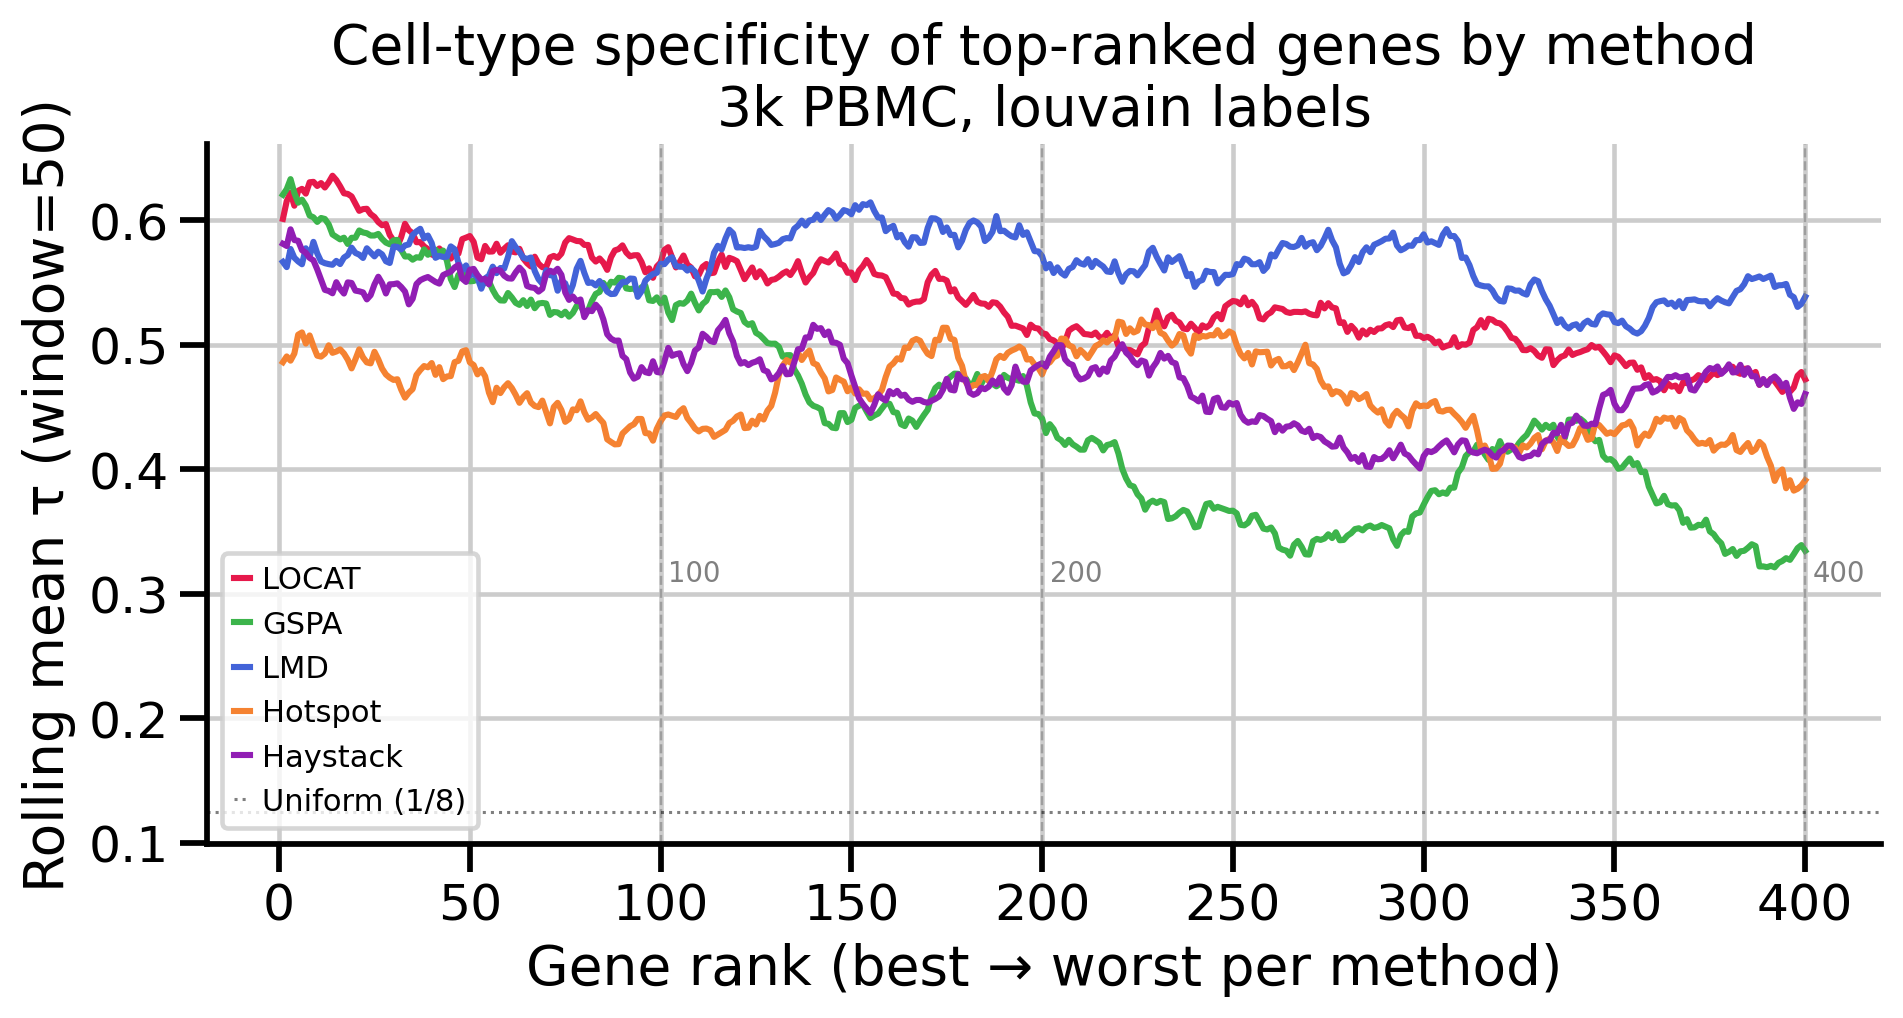

In [12]:
WINDOW = 50
MAX_RANK = 400
CUTOFFS = [100, 200, 400]

fig, ax = plt.subplots(figsize=(9, 5))

colors = {
    "LOCAT":    "#e6194b",
    "GSPA":     "#3cb44b",
    "LMD":      "#4363d8",
    "Hotspot":  "#f58231",
    "Haystack": "#911eb4",
}

for method, ranked in method_rankings.items():
    # filter to genes that have a specificity score
    ranked_valid = [g for g in ranked if g in specificity.index and not np.isnan(specificity[g])]
    taus = np.array([specificity[g] for g in ranked_valid[:MAX_RANK]])
    ranks = np.arange(1, len(taus) + 1)
    
    # rolling mean
    roll = pd.Series(taus).rolling(window=WINDOW, center=True, min_periods=1).mean().values
    ax.plot(ranks, roll, label=method, color=colors[method], linewidth=2)

for c in CUTOFFS:
    ax.axvline(c, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(c + 2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.1, str(c),
            fontsize=9, color="gray", va="bottom")

ax.axhline(1/K, color="black", linestyle=":", linewidth=1, alpha=0.5, label=f"Uniform (1/{K})")
ax.set_xlabel("Gene rank (best → worst per method)")
ax.set_ylabel(f"Rolling mean τ (window={WINDOW})")
ax.set_title("Cell-type specificity of top-ranked genes by method\n3k PBMC, louvain labels")
ax.legend(frameon=True, fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / "specificity_rolling_mean.svg", bbox_inches="tight")
plt.show()

## Bar chart: mean τ at top-K cutoffs

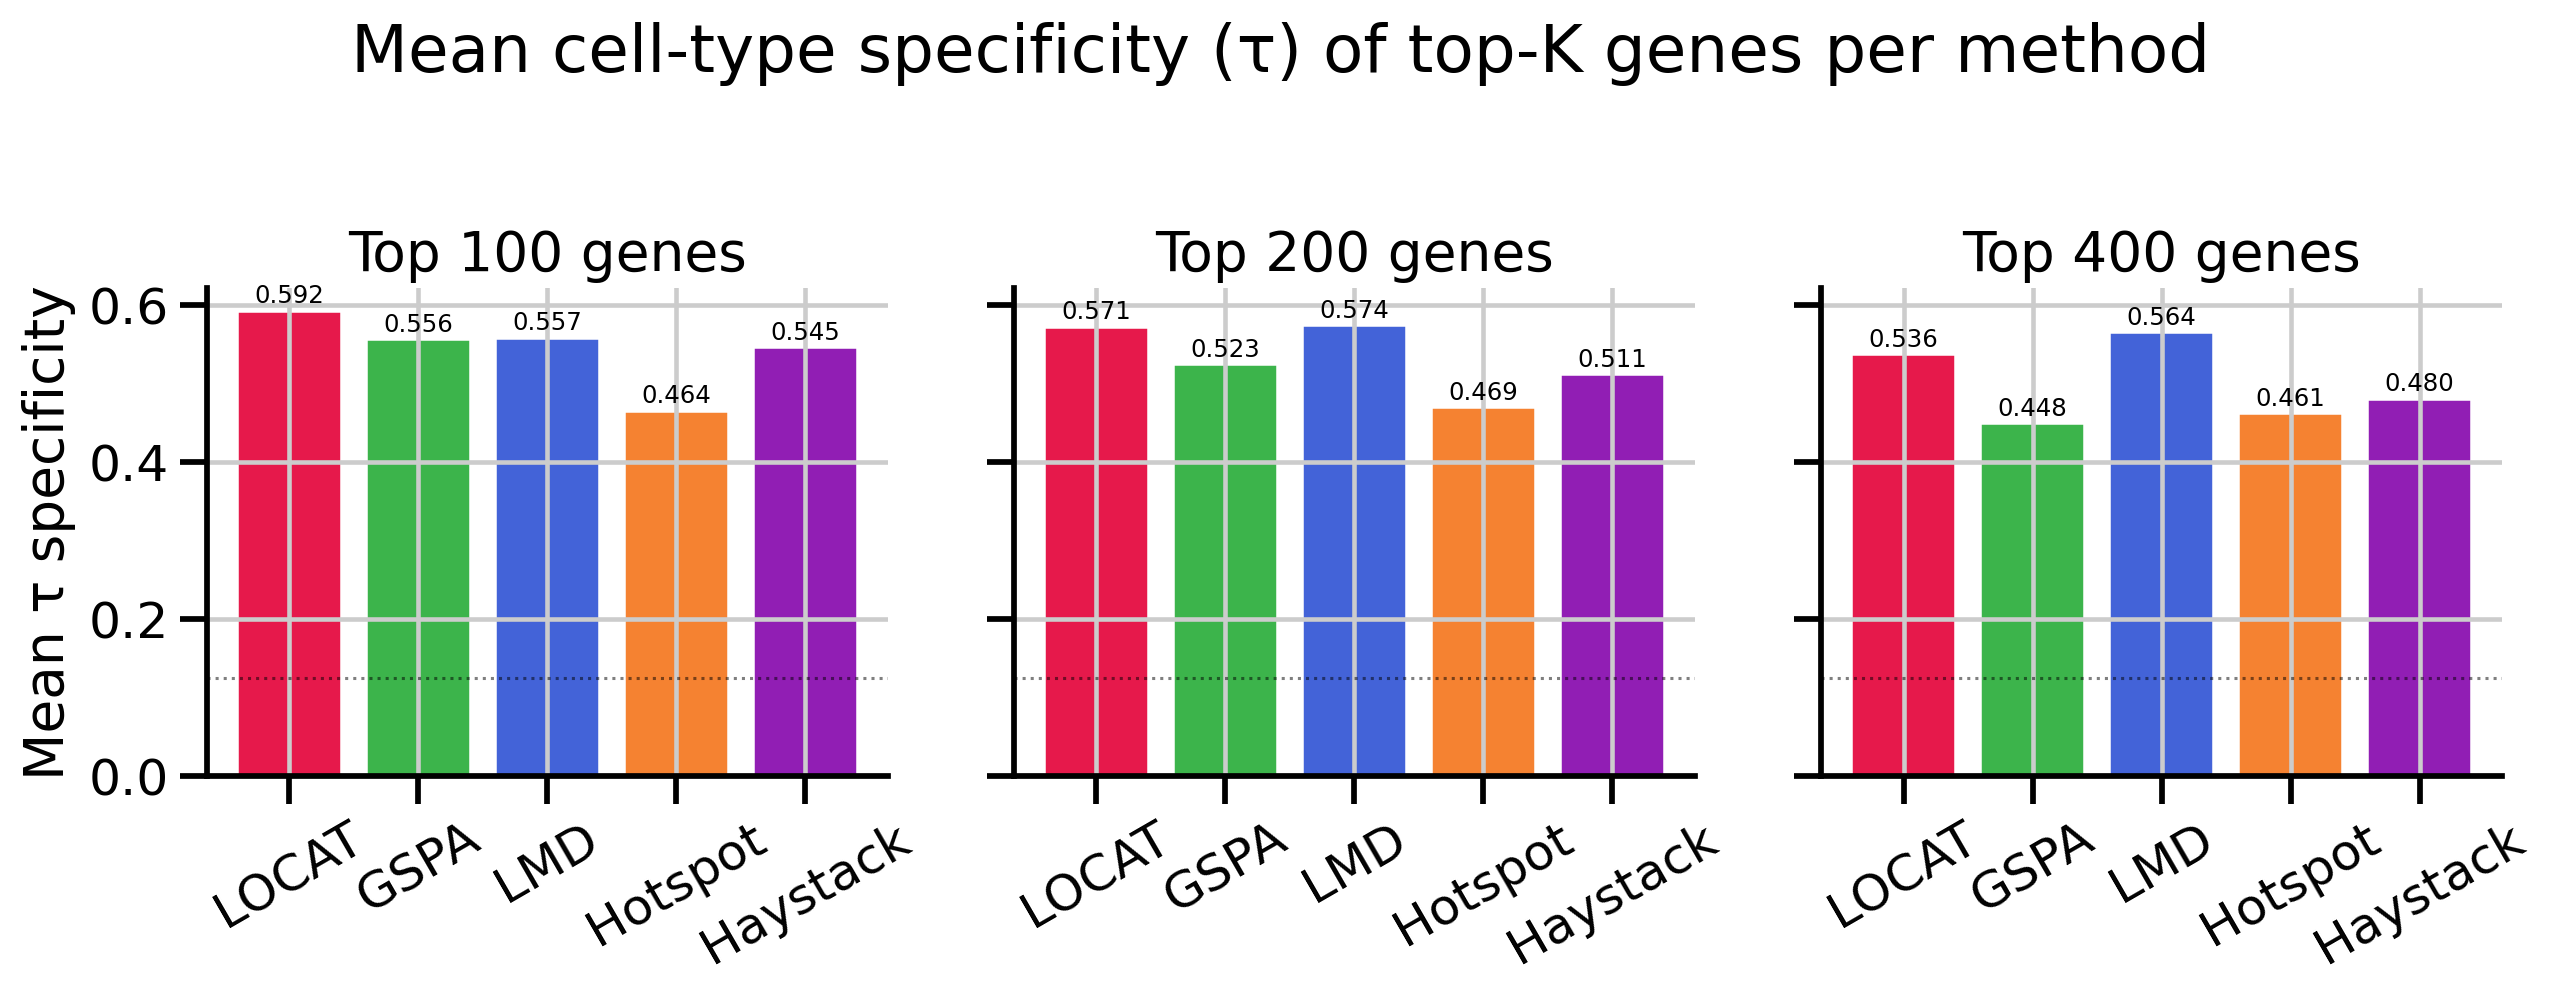

In [13]:
fig, axes = plt.subplots(1, len(CUTOFFS), figsize=(4 * len(CUTOFFS), 4.5), sharey=True)

for ax, K_cut in zip(axes, CUTOFFS):
    means = {}
    for method, ranked in method_rankings.items():
        ranked_valid = [g for g in ranked if g in specificity.index and not np.isnan(specificity[g])]
        top = ranked_valid[:K_cut]
        means[method] = np.mean([specificity[g] for g in top])
    
    methods = list(means.keys())
    vals = [means[m] for m in methods]
    bar_colors = [colors[m] for m in methods]
    
    bars = ax.bar(methods, vals, color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.axhline(1/K, color="black", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_title(f"Top {K_cut} genes")
    ax.set_ylabel("Mean τ specificity" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)

fig.suptitle("Mean cell-type specificity (τ) of top-K genes per method", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / "specificity_bar_topK.svg", bbox_inches="tight")
plt.show()

## Cumulative specificity: fraction of top-K genes exceeding a threshold τ > 0.5

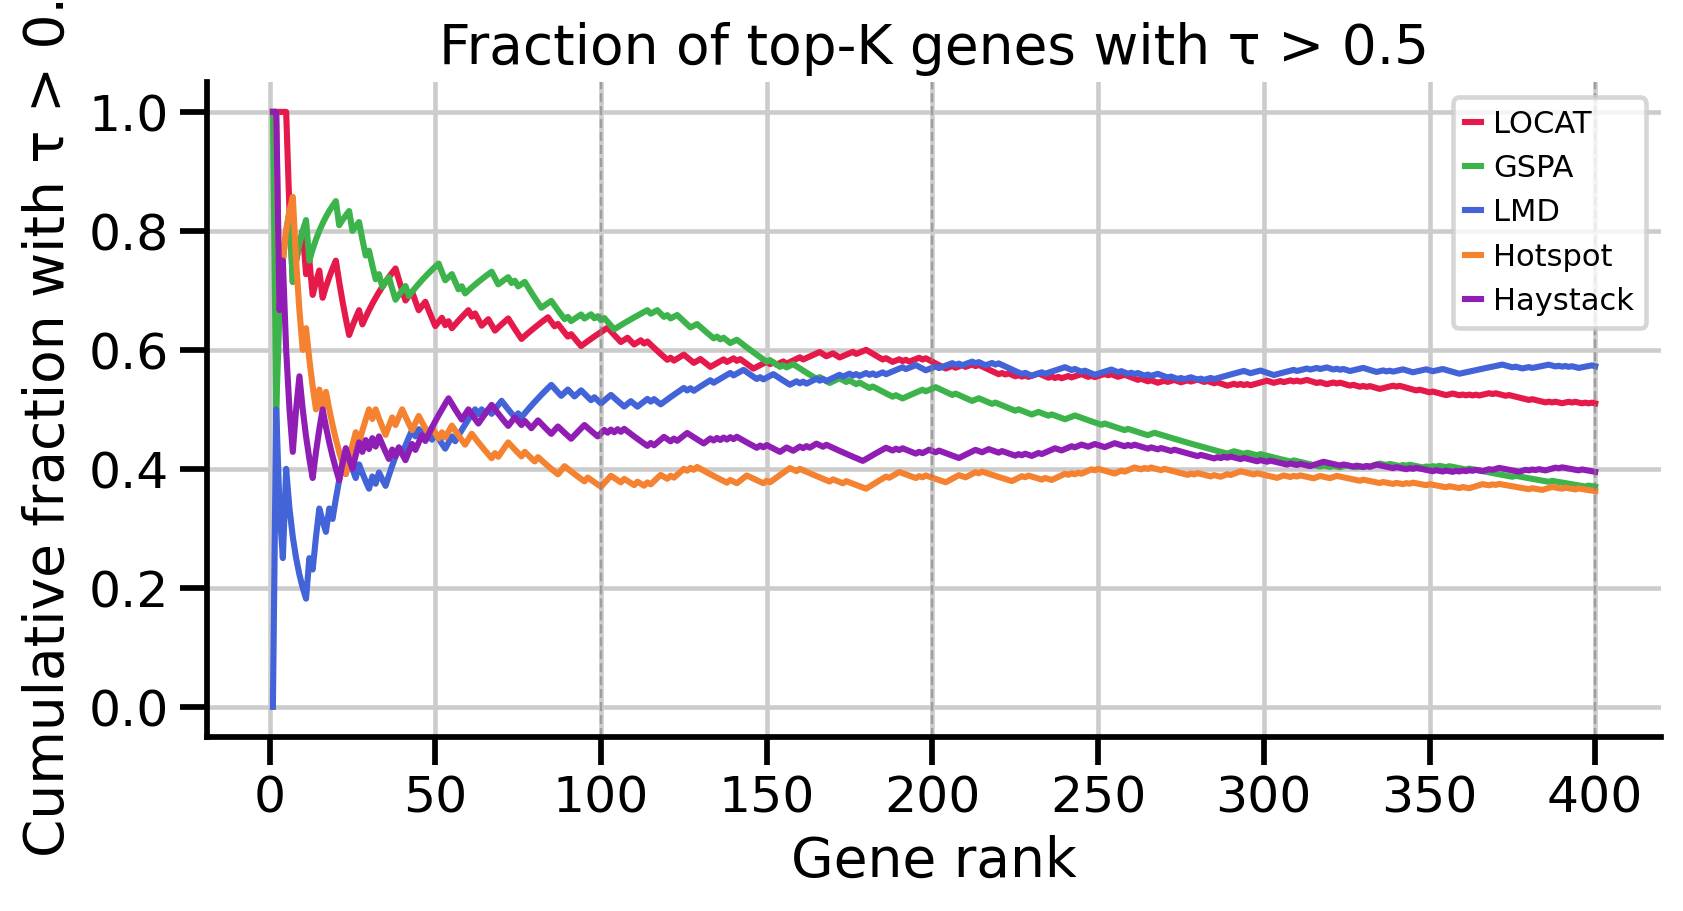

In [14]:
THRESH = 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))

for method, ranked in method_rankings.items():
    ranked_valid = [g for g in ranked if g in specificity.index and not np.isnan(specificity[g])]
    taus = np.array([specificity[g] for g in ranked_valid[:MAX_RANK]])
    cumfrac = np.cumsum(taus > THRESH) / (np.arange(len(taus)) + 1)
    ax.plot(np.arange(1, len(taus) + 1), cumfrac,
            label=method, color=colors[method], linewidth=2)

for c in CUTOFFS:
    ax.axvline(c, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Gene rank")
ax.set_ylabel(f"Cumulative fraction with τ > {THRESH}")
ax.set_title(f"Fraction of top-K genes with τ > {THRESH}")
ax.legend(frameon=True, fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / "specificity_cumfrac.svg", bbox_inches="tight")
plt.show()

## Summary table

In [15]:
rows = []
for method, ranked in method_rankings.items():
    ranked_valid = [g for g in ranked if g in specificity.index and not np.isnan(specificity[g])]
    for K_cut in CUTOFFS:
        top = ranked_valid[:K_cut]
        taus = [specificity[g] for g in top]
        rows.append({
            "Method": method,
            "Top-K": K_cut,
            "Mean τ": np.mean(taus),
            f"Frac τ>{THRESH}": np.mean(np.array(taus) > THRESH),
        })

summary_df = pd.DataFrame(rows).pivot(index="Method", columns="Top-K", values=["Mean τ", f"Frac τ>{THRESH}"])
summary_df.columns = [f"{v} @ top-{k}" for v, k in summary_df.columns]
display(summary_df.round(3))
summary_df.to_csv(OUT_DIR / "specificity_summary.csv")
print("Saved specificity_summary.csv")

,Mean τ @ top-100,Mean τ @ top-200,Mean τ @ top-400,Frac τ>0.5 @ top-100,Frac τ>0.5 @ top-200,Frac τ>0.5 @ top-400
Method,,,,,,
GSPA,0.556,0.523,0.448,0.65,0.535,0.370
Haystack,0.545,0.511,0.480,0.46,0.430,0.395
Hotspot,0.464,0.469,0.461,0.37,0.385,0.362
LMD,0.557,0.574,0.564,0.51,0.570,0.572
LOCAT,0.592,0.571,0.536,0.63,0.580,0.510


Saved specificity_summary.csv


## Violin plot: τ distribution for top-100 genes per method

/tmp/claude-6071/ipykernel_3422895/420824592.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


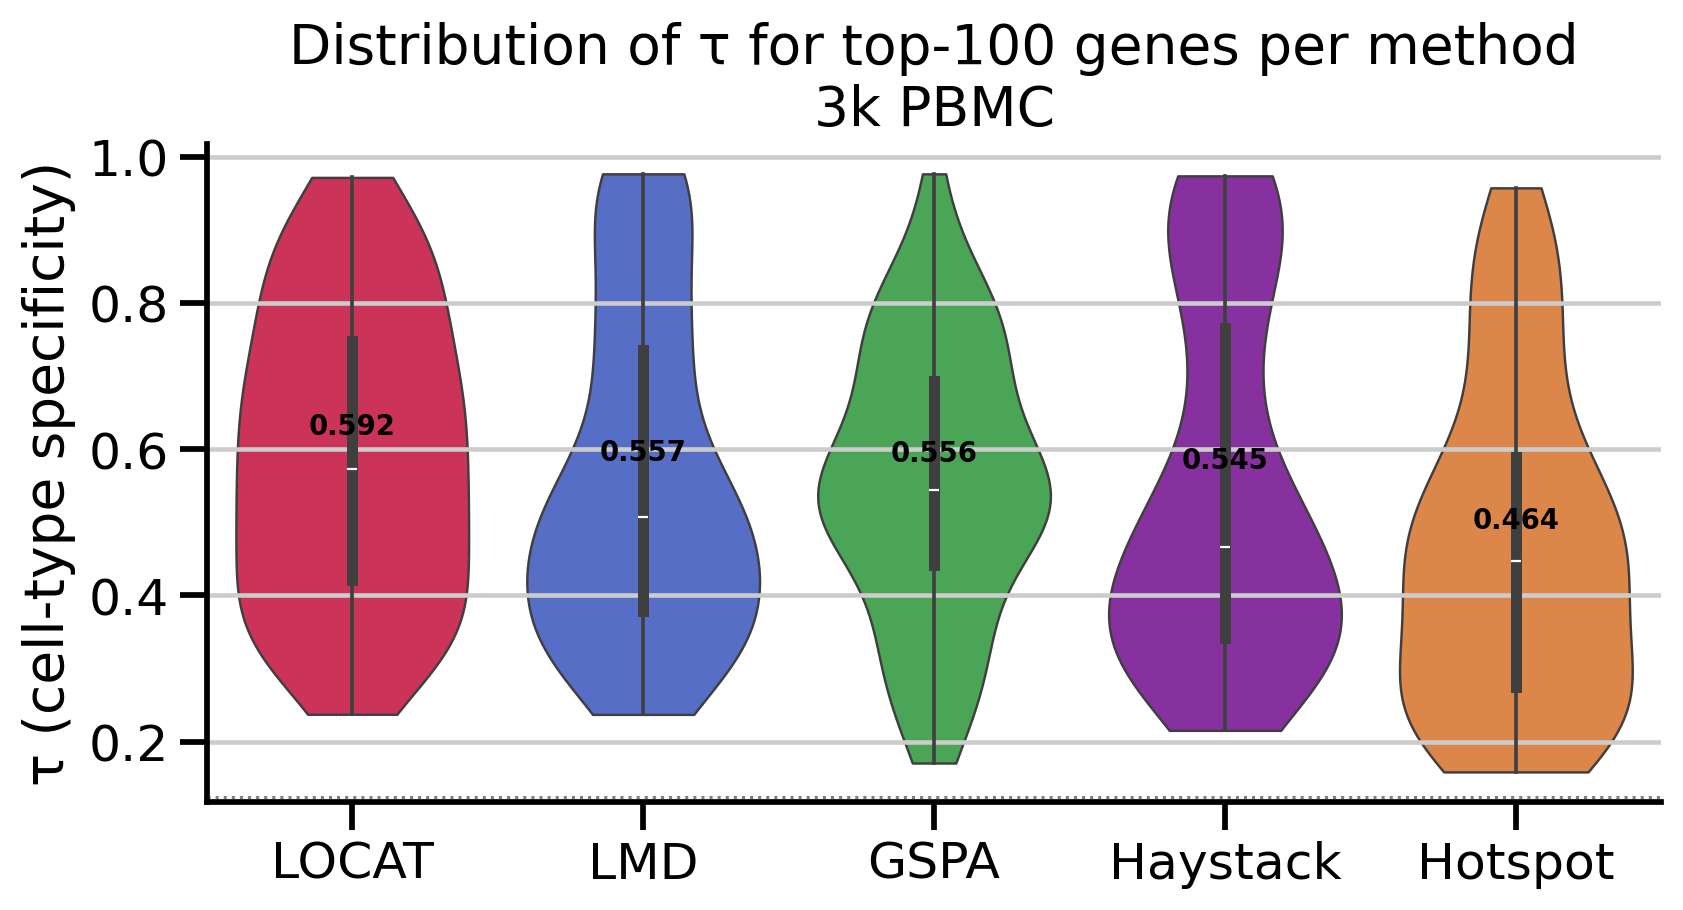

In [16]:
TOP_N = 100

violin_data = []
for method, ranked in method_rankings.items():
    ranked_valid = [g for g in ranked if g in specificity.index and not np.isnan(specificity[g])]
    top = ranked_valid[:TOP_N]
    for g in top:
        violin_data.append({"Method": method, "tau": specificity[g]})

vdf = pd.DataFrame(violin_data)

method_order = sorted(method_rankings.keys(), key=lambda m: -vdf[vdf.Method==m]["tau"].mean())
palette = {m: colors[m] for m in method_order}

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(
    data=vdf, x="Method", y="tau",
    order=method_order, palette=palette,
    inner="box", cut=0, linewidth=0.8, ax=ax,
)
ax.axhline(1/K, color="black", linestyle=":", linewidth=1, alpha=0.5, label=f"Uniform (1/{K})")

# annotate means
for i, m in enumerate(method_order):
    mean_val = vdf[vdf.Method==m]["tau"].mean()
    ax.text(i, mean_val + 0.02, f"{mean_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("")
ax.set_ylabel("τ (cell-type specificity)")
ax.set_title(f"Distribution of τ for top-{TOP_N} genes per method\n3k PBMC")
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / "specificity_violin_top100.svg", bbox_inches="tight")
plt.show()

## UMAP panels: top 6 genes per method

Visual confirmation — do the top-scoring genes from each method light up individual cell types?

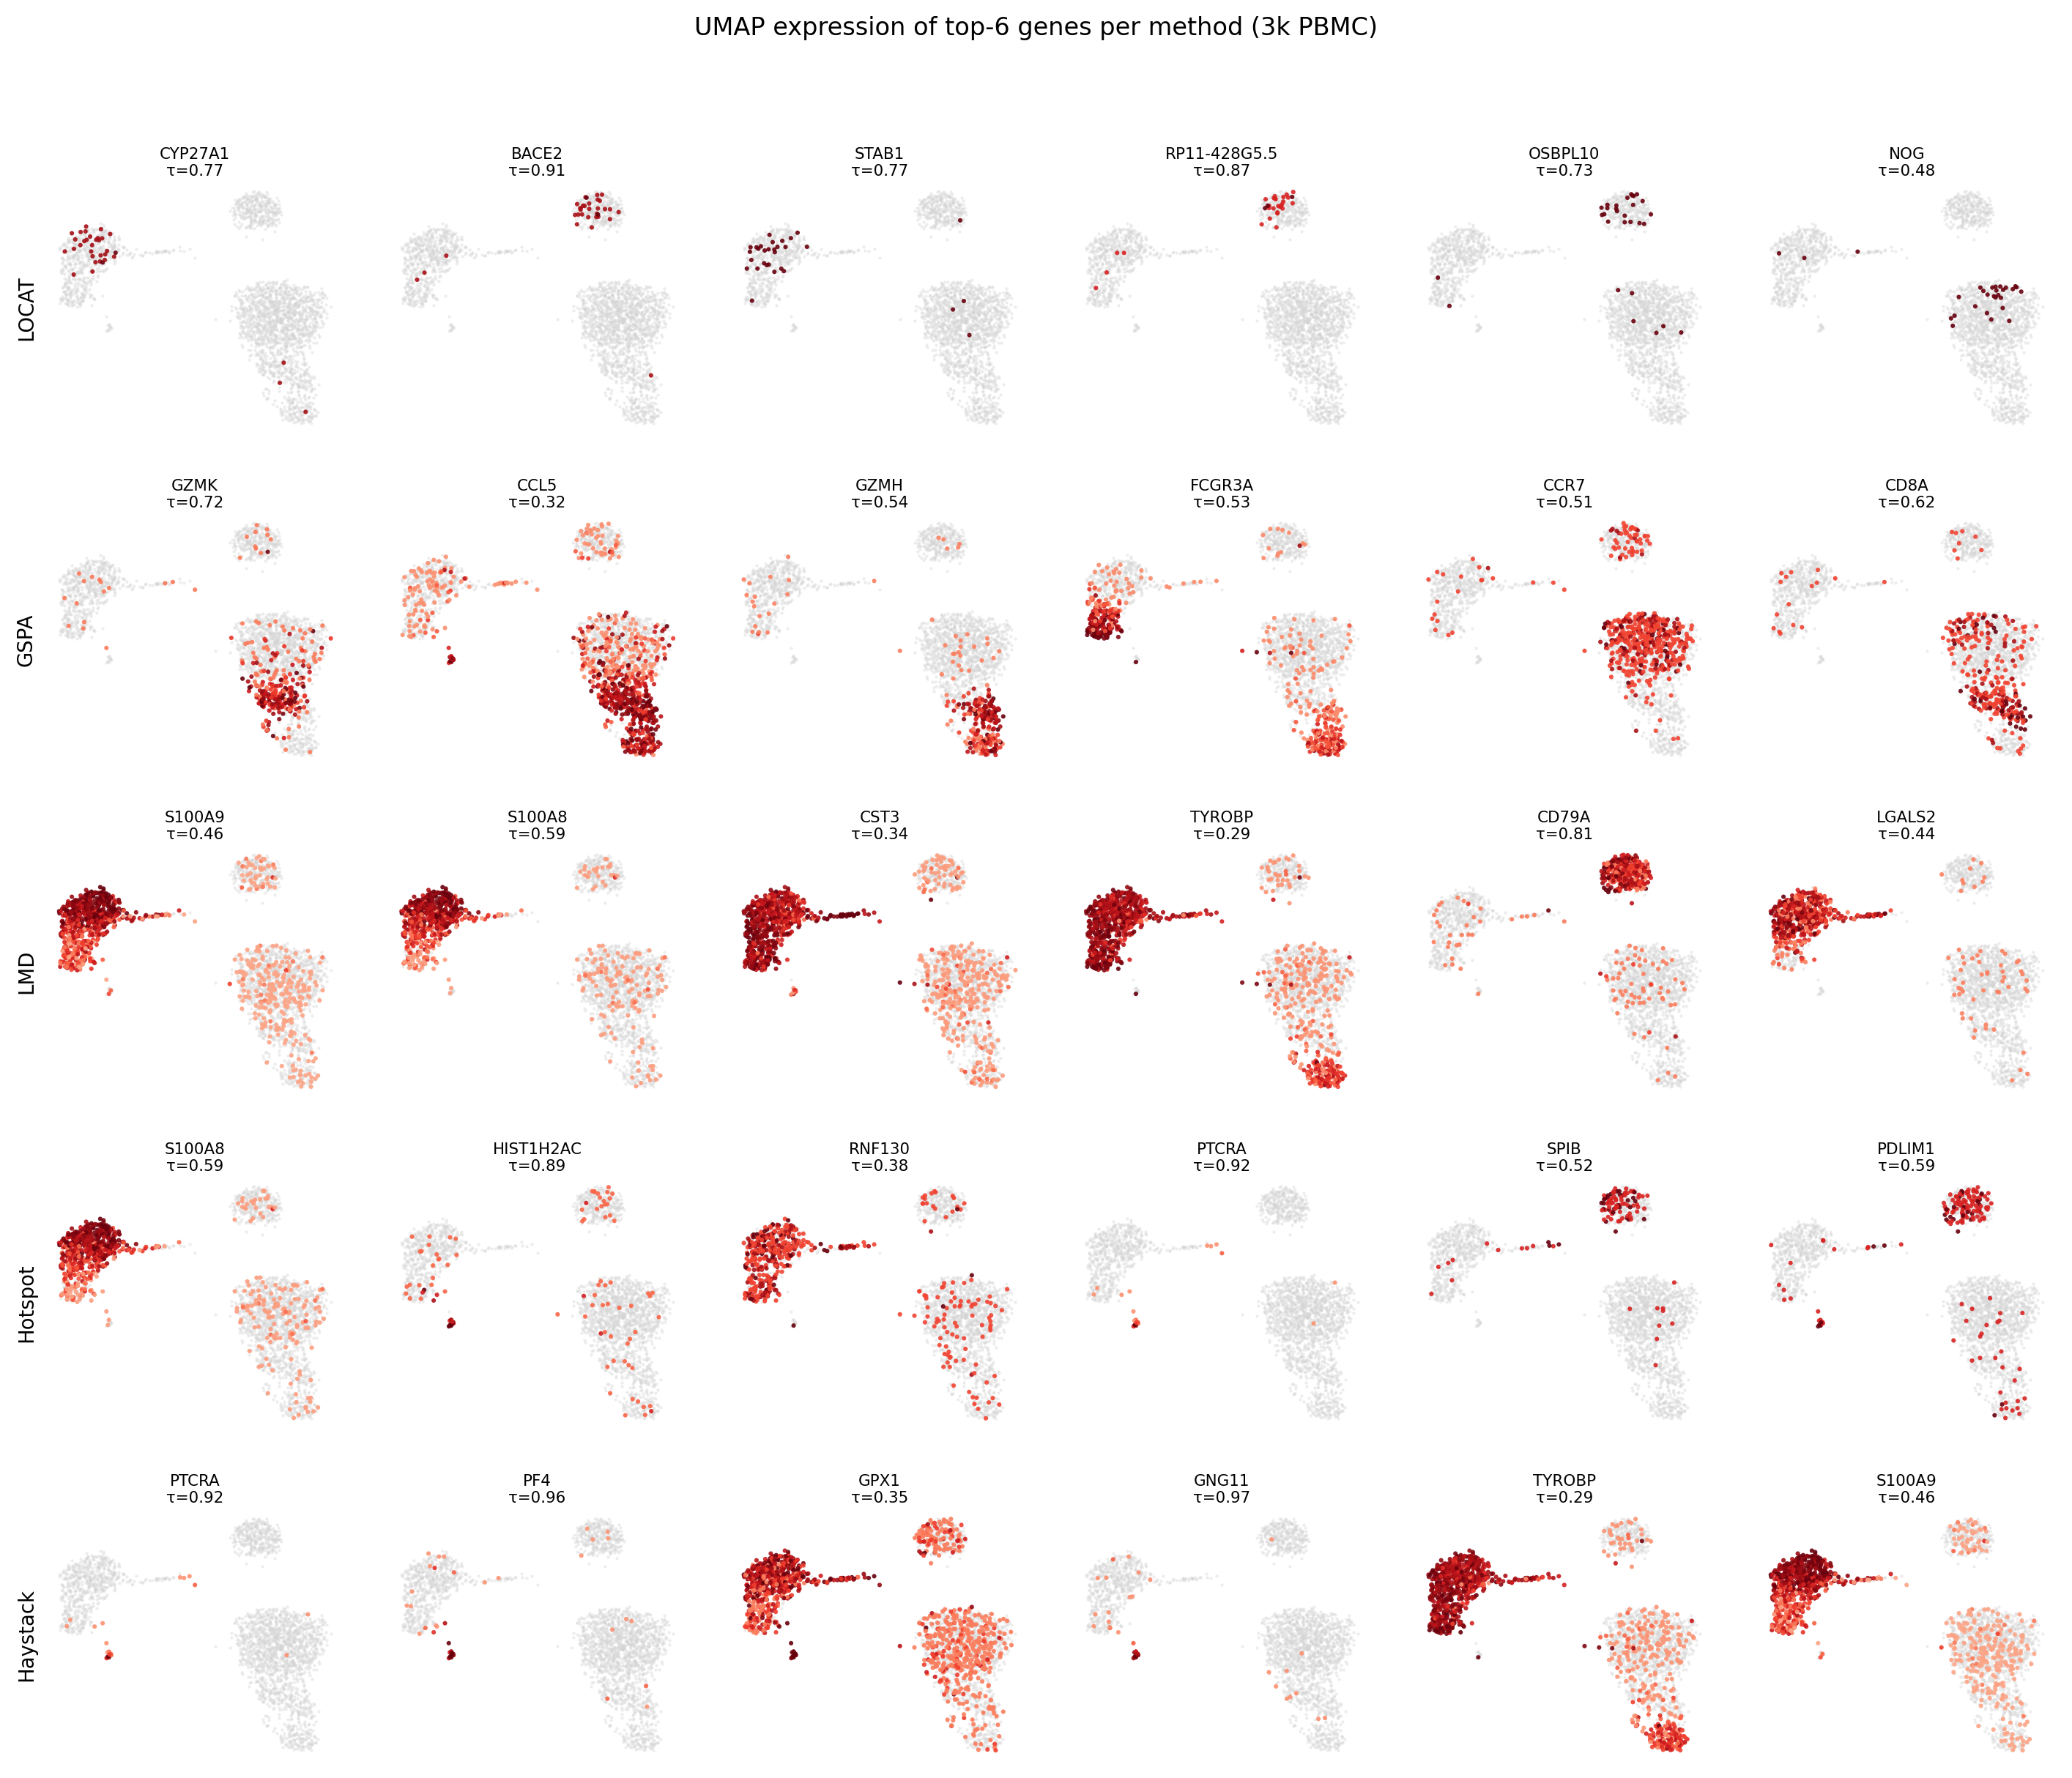

In [17]:
import scipy.sparse as sp

N_SHOW = 6

def get_expr(adata, gene):
    x = adata[:, gene].X
    if sp.issparse(x):
        x = x.toarray().ravel()
    return np.asarray(x).ravel()

umap_coords = adata.obsm["X_umap"]
louvain_colors_map = dict(zip(
    adata.obs["louvain"].cat.categories,
    adata.uns["louvain_colors"]
))

fig, axes = plt.subplots(
    len(method_rankings), N_SHOW,
    figsize=(N_SHOW * 2.2, len(method_rankings) * 2.2),
    squeeze=False
)

for row_i, (method, ranked) in enumerate(method_rankings.items()):
    ranked_valid = [g for g in ranked if g in adata.var_names and g in specificity.index]
    top_genes = ranked_valid[:N_SHOW]

    for col_i, gene in enumerate(top_genes):
        ax = axes[row_i, col_i]
        x = get_expr(adata, gene)
        x_plot = np.log1p(x)
        expr_mask = x_plot > 0
        vmax = np.percentile(x_plot[expr_mask], 95) if expr_mask.any() else 1.0
        tau_val = specificity.get(gene, np.nan)

        ax.scatter(umap_coords[~expr_mask, 0], umap_coords[~expr_mask, 1],
                   c="lightgray", s=2, alpha=0.4, linewidths=0, rasterized=True)
        ax.scatter(umap_coords[expr_mask, 0], umap_coords[expr_mask, 1],
                   c=np.clip(x_plot[expr_mask], 0, vmax),
                   s=4, alpha=0.9, cmap="Reds", vmin=0, vmax=vmax,
                   linewidths=0, rasterized=True)
        ax.set_title(f"{gene}\nτ={tau_val:.2f}", fontsize=7, pad=2)
        ax.set_xticks([]); ax.set_yticks([])
        for sp_ in ax.spines.values(): sp_.set_visible(False)

    # row label
    axes[row_i, 0].set_ylabel(method, fontsize=9, labelpad=4)

plt.suptitle(f"UMAP expression of top-{N_SHOW} genes per method (3k PBMC)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap_top_genes_per_method.svg", bbox_inches="tight", dpi=150)
plt.show()

## Rank overlap heatmap (Jaccard @ top-100)

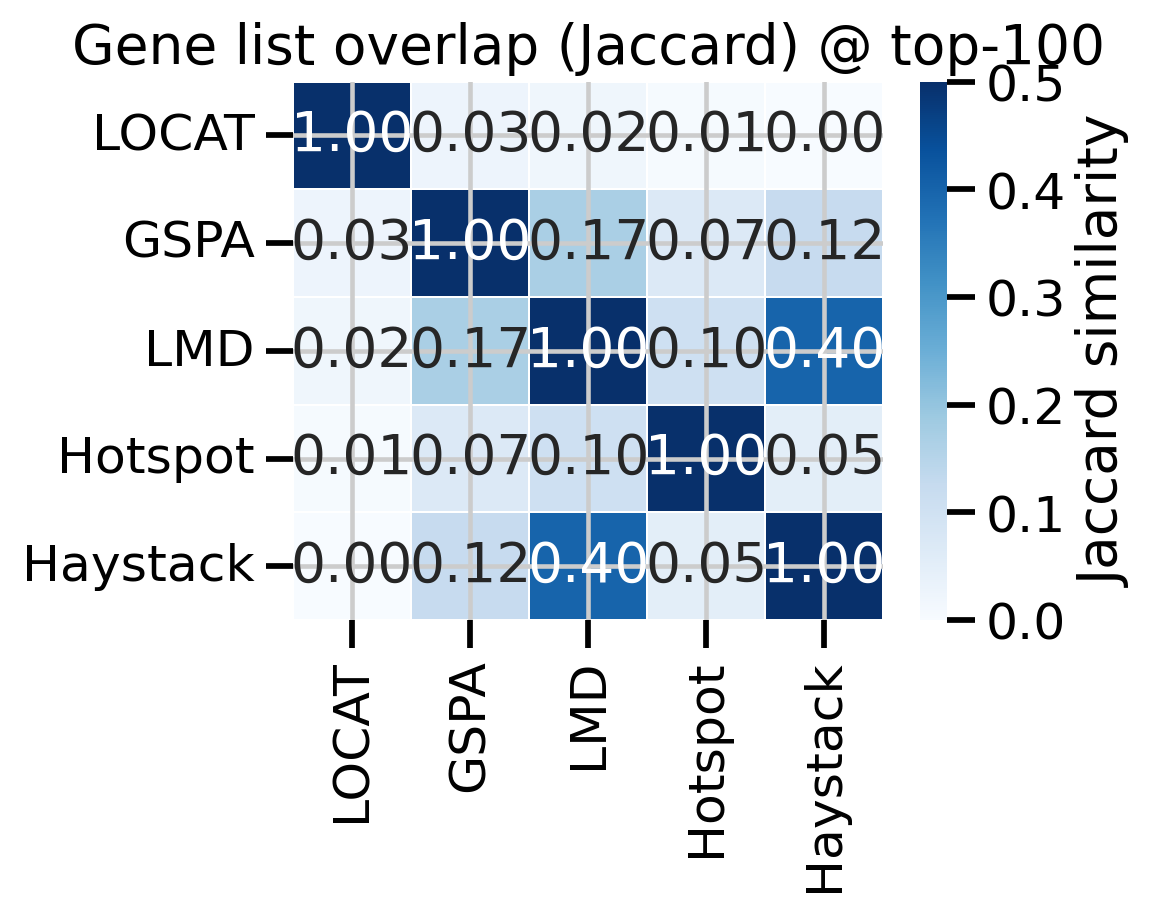


Locat vs Hotspot: 0.005
Locat vs LMD:     0.020
Locat vs GSPA:    0.026


In [18]:
from itertools import combinations

TOP_OVERLAP = 100
methods = list(method_rankings.keys())

def jaccard(a, b):
    sa, sb = set(a), set(b)
    inter = len(sa & sb)
    union = len(sa | sb)
    return inter / union if union else 0.0

top_sets = {m: set(
    [g for g in method_rankings[m] if g in specificity.index and not np.isnan(specificity[g])][:TOP_OVERLAP]
) for m in methods}

jac_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    for m2 in methods:
        jac_matrix.loc[m1, m2] = jaccard(top_sets[m1], top_sets[m2])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
mask = np.eye(len(methods), dtype=bool)
sns.heatmap(
    jac_matrix.astype(float),
    annot=True, fmt=".2f", cmap="Blues",
    vmin=0, vmax=0.5,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Jaccard similarity"},
)
ax.set_title(f"Gene list overlap (Jaccard) @ top-{TOP_OVERLAP}")
plt.tight_layout()
plt.savefig(OUT_DIR / "rank_overlap_jaccard.svg", bbox_inches="tight")
plt.show()

print(f"\nLocat vs Hotspot: {jac_matrix.loc['LOCAT','Hotspot']:.3f}")
print(f"Locat vs LMD:     {jac_matrix.loc['LOCAT','LMD']:.3f}")
print(f"Locat vs GSPA:    {jac_matrix.loc['LOCAT','GSPA']:.3f}")

---
## Option A: All methods restricted to 1838 HVGs

Same gene universe as the paper's FigS1/DermalC analyses. Eliminates bias from LOCAT ranking ultra-rare non-HVG genes.

In [19]:
DATA_HVG = Path("/banach2/wes/Locat-paper-repro-private/data/pbmc3k_hvg_lognorm.h5ad")
assert DATA_HVG.exists(), DATA_HVG

reset_seeds()
adata_hvg = sc.read_h5ad(DATA_HVG)
print(adata_hvg)

# Recompute tau on HVG gene set
X_hvg = adata_hvg.X.toarray() if sp.issparse(adata_hvg.X) else np.asarray(adata_hvg.X)
cell_types_hvg = adata_hvg.obs['louvain'].cat.categories.tolist()
K_hvg = len(cell_types_hvg)

mean_per_ct_hvg = np.array([X_hvg[adata_hvg.obs['louvain']==ct].mean(axis=0) for ct in cell_types_hvg])
row_sums_hvg = mean_per_ct_hvg.sum(axis=0)
expressed_hvg = row_sums_hvg > 0
tau_hvg_arr = np.where(expressed_hvg, mean_per_ct_hvg.max(axis=0)/row_sums_hvg, np.nan)
specificity_hvg = pd.Series(tau_hvg_arr, index=adata_hvg.var_names, name="tau_hvg")
print(f"HVG tau: {(~specificity_hvg.isna()).sum()} genes scored, median={specificity_hvg.dropna().median():.3f}")

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_draw_graph_fr', 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'
HVG tau: 1838 genes scored, median=0.299


In [20]:
# ── LOCAT on HVGs ──
LOCAT_HVG_PATH = OUT_DIR / "locat_scores_hvg.npz"

if LOCAT_HVG_PATH.exists():
    print("Loading cached LOCAT-HVG results...")
    d = np.load(LOCAT_HVG_PATH, allow_pickle=True)
    locat_hvg_ranked = pd.Series(d["pval"], index=d["gene_names"]).sort_values().index.tolist()
else:
    reset_seeds()
    embedding_hvg = adata_hvg.obsm["X_pca"].astype(np.float64)[:, :8]
    w_transform = lambda x: np.clip(np.asarray(x), 0.0, np.inf)

    model = LOCAT(adata=adata_hvg, cell_embedding=embedding_hvg, k=20,
                  n_bootstrap_inits=50, show_progress=True,
                  knn=adata_hvg.obsp["connectivities"], knn_mode="connectivity")
    model._reg_covar = 1e-6
    results = model.gmm_scan(weights_transform=w_transform, max_freq=0.9,
                             include_depletion_scan=True,
                             rc_lambda_values=np.linspace(1.0, 2.0, 8))
    rows = [{"gene": g, "pval": r._asdict()["pval"],
             "concentration_pval": r._asdict()["concentration_pval"],
             "depletion_pval": r._asdict()["depletion_pval"]}
            for g, r in results.items()]
    df = pd.DataFrame(rows).set_index("gene").sort_values("pval")
    np.savez(LOCAT_HVG_PATH, gene_names=df.index.values, pval=df["pval"].values,
             concentration_pval=df["concentration_pval"].values,
             depletion_pval=df["depletion_pval"].values)
    locat_hvg_ranked = df.index.tolist()
    print(f"LOCAT-HVG done: {len(locat_hvg_ranked)} genes")

print("LOCAT-HVG top-10:", locat_hvg_ranked[:10])

Loading cached LOCAT-HVG results...
LOCAT-HVG top-10: ['FCRL2', 'ICOSLG', 'RP11-164H13.1', 'ZNF718', 'NMNAT3', 'PMEPA1', 'C16orf52', 'PDZD4', 'FCAR', 'FCGR3B']


In [21]:
# ── GSPA on HVGs ──
GSPA_HVG_PATH = OUT_DIR / "gspa_scores_hvg.npz"
if GSPA_HVG_PATH.exists():
    print("Loading cached GSPA-HVG results...")
else:
    print("Running GSPA-HVG subprocess...")
    result = subprocess.run(
        ["/banach2/wes/.conda/envs/gspa-env/bin/python", "run_gspa_hvg.py"],
        env={**os.environ, "CUDA_VISIBLE_DEVICES": "2"})
    if result.returncode != 0:
        raise RuntimeError(f"GSPA-HVG subprocess failed (rc={result.returncode})")
d = np.load(GSPA_HVG_PATH, allow_pickle=True)
# GSPA: sort descending (higher localization score = more localized; per DermalC paper code)
gspa_hvg_ranked = pd.Series(d["gene_localization"], index=d["var_names"]).sort_values(ascending=False).index.tolist()
print("GSPA-HVG top-10:", gspa_hvg_ranked[:10])

Loading cached GSPA-HVG results...
GSPA-HVG top-10: ['GZMK', 'CCL5', 'FCGR3A', 'GZMH', 'NKG7', 'FCER1A', 'CLEC10A', 'GNLY', 'GZMB', 'GZMA']


In [22]:
# ── LMD on HVGs ──
LMD_HVG_PATH = OUT_DIR / "lmd_scores_hvg.npz"
if LMD_HVG_PATH.exists():
    print("Loading cached LMD-HVG results...")
else:
    print("Running LMD-HVG subprocess...")
    lmd_env = {**os.environ, "R_HOME": "/banach2/wes/envs/lmd_rpy2/lib/R",
               "R_DEFAULT_PACKAGES": "base,utils,stats,graphics,grDevices,methods",
               "CUDA_VISIBLE_DEVICES": ""}
    result = subprocess.run(["/banach2/wes/envs/lmd_rpy2/bin/python", "run_lmd_hvg.py"], env=lmd_env)
    if result.returncode != 0:
        raise RuntimeError(f"LMD-HVG subprocess failed (rc={result.returncode})")
d = np.load(LMD_HVG_PATH, allow_pickle=True)
# LMD: sort ascending (lower score = more localized; per DermalC paper code)
lmd_hvg_ranked = pd.Series(d["lmd_score"], index=d["var_names"]).sort_values(ascending=True).index.tolist()
print("LMD-HVG top-10:", lmd_hvg_ranked[:10])

Loading cached LMD-HVG results...
LMD-HVG top-10: ['LY6G6F', 'GP9', 'AP001189.4', 'ITGA2B', 'S100A8', 'CST3', 'CLDN5', 'RP11-879F14.2', 'TYROBP', 'CD79A']


In [23]:
# ── Hotspot on HVGs ──
HS_HVG_PATH = OUT_DIR / "hotspot_scores_hvg.npz"
if HS_HVG_PATH.exists():
    d = np.load(HS_HVG_PATH, allow_pickle=True)
    hotspot_hvg_ranked = pd.Series(d["fdr"], index=d["var_names"]).sort_values().index.tolist()
    print("Loading cached Hotspot-HVG results...")
else:
    import hotspot as hs_pkg
    reset_seeds()
    hs = hs_pkg.Hotspot(adata_hvg, layer_key=None, model="normal",
                        latent_obsm_key="X_pca", umi_counts_obs_key=None)
    hs.create_knn_graph(weighted_graph=False, n_neighbors=30)
    hs.compute_autocorrelations()
    hotspot_hvg_ranked = hs.results["FDR"].sort_values().index.tolist()
    np.savez(HS_HVG_PATH, var_names=np.array(hs.results.index), fdr=hs.results["FDR"].values)
    print("Hotspot-HVG done")
print("Hotspot-HVG top-10:", hotspot_hvg_ranked[:10])

Loading cached Hotspot-HVG results...
Hotspot-HVG top-10: ['S100A8', 'SPIB', 'HIST1H2AC', 'IRF8', 'PTCRA', 'TNFSF13B', 'SRGN', 'ASGR1', 'HVCN1', 'S1PR5']


In [24]:
# ── Haystack on HVGs ──
HAY_HVG_PATH = OUT_DIR / "haystack_scores_hvg.npz"
if HAY_HVG_PATH.exists():
    d = np.load(HAY_HVG_PATH, allow_pickle=True)
    haystack_hvg_ranked = pd.Series(d["logpval"], index=d["var_names"]).sort_values().index.tolist()
    print("Loading cached Haystack-HVG results...")
else:
    import singleCellHaystack as sch
    reset_seeds()
    res = sch.haystack(adata_hvg, coord="pca")
    haystack_hvg_ranked = res.result.set_index("gene")["logpval"].sort_values().index.tolist()
    np.savez(HAY_HVG_PATH,
             var_names=res.result["gene"].values,
             logpval=res.result["logpval"].values)
    print("Haystack-HVG done")
print("Haystack-HVG top-10:", haystack_hvg_ranked[:10])

Loading cached Haystack-HVG results...
Haystack-HVG top-10: ['LY6G6F', 'SPOCD1', 'RP11-879F14.2', 'CLDN5', 'GP9', 'AP001189.4', 'ITGA2B', 'TMEM40', 'SEPT5', 'PTCRA']


/tmp/claude-6071/ipykernel_3422895/64536617.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=vdf_hvg, x="Method", y="tau", order=order_hvg,


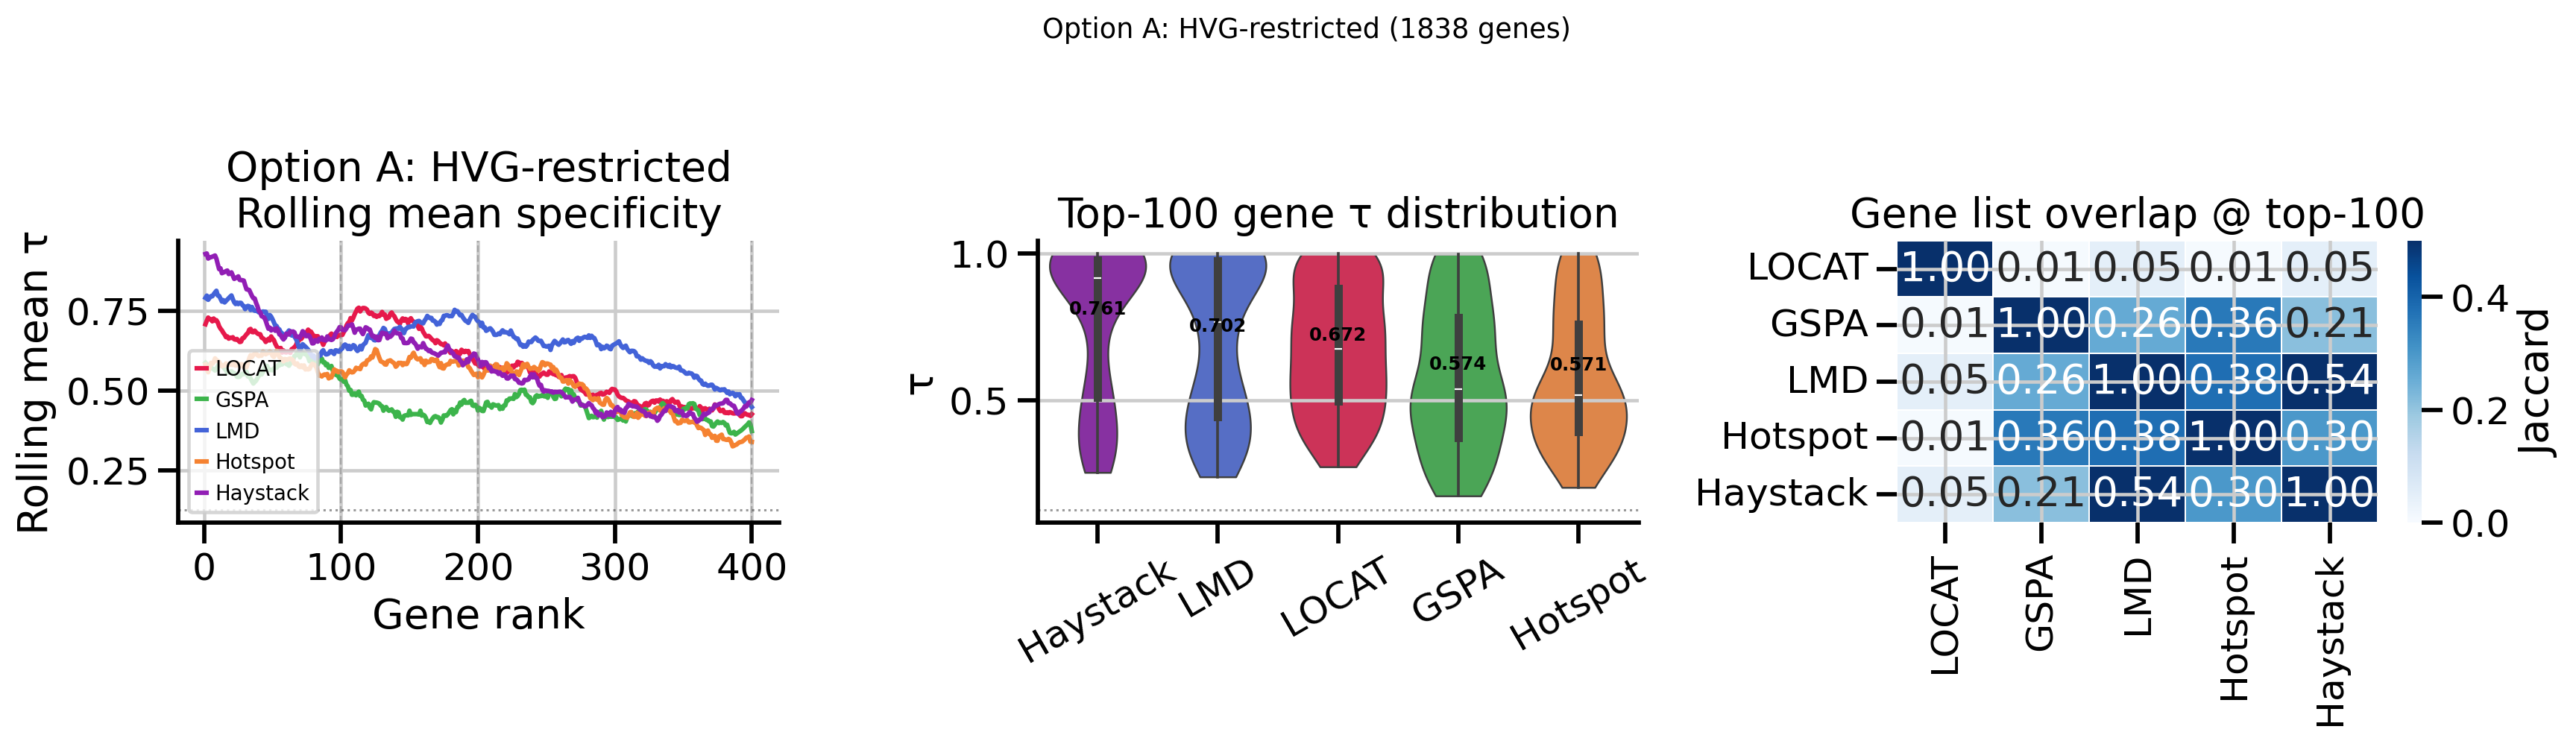


=== Option A summary ===


,Mean τ @ top-100,Mean τ @ top-200,Mean τ @ top-400,Frac τ>0.5 @ top-100,Frac τ>0.5 @ top-200,Frac τ>0.5 @ top-400
Method,,,,,,
GSPA,0.574,0.508,0.474,0.58,0.435,0.362
Haystack,0.761,0.703,0.586,0.76,0.735,0.538
Hotspot,0.571,0.587,0.525,0.55,0.545,0.438
LMD,0.702,0.699,0.653,0.68,0.710,0.678
LOCAT,0.672,0.681,0.588,0.75,0.745,0.572


In [25]:
# ── Option A comparison plots ──
method_rankings_hvg = {
    "LOCAT":    locat_hvg_ranked,
    "GSPA":     gspa_hvg_ranked,
    "LMD":      lmd_hvg_ranked,
    "Hotspot":  hotspot_hvg_ranked,
    "Haystack": haystack_hvg_ranked,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Rolling mean curve
ax = axes[0]
for method, ranked in method_rankings_hvg.items():
    ranked_v = [g for g in ranked if g in specificity_hvg.index and not np.isnan(specificity_hvg[g])]
    taus = np.array([specificity_hvg[g] for g in ranked_v[:MAX_RANK]])
    roll = pd.Series(taus).rolling(window=WINDOW, center=True, min_periods=1).mean().values
    ax.plot(np.arange(1, len(taus)+1), roll, label=method, color=colors[method], linewidth=2)
for c in CUTOFFS: ax.axvline(c, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(1/K_hvg, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.set_xlabel("Gene rank"); ax.set_ylabel("Rolling mean τ")
ax.set_title("Option A: HVG-restricted\nRolling mean specificity")
ax.legend(fontsize=9); sns.despine(ax=ax)

# Violin
ax = axes[1]
vdata = []
for method, ranked in method_rankings_hvg.items():
    ranked_v = [g for g in ranked if g in specificity_hvg.index and not np.isnan(specificity_hvg[g])]
    for g in ranked_v[:100]: vdata.append({"Method": method, "tau": specificity_hvg[g]})
vdf_hvg = pd.DataFrame(vdata)
order_hvg = sorted(method_rankings_hvg.keys(), key=lambda m: -vdf_hvg[vdf_hvg.Method==m]["tau"].mean())
sns.violinplot(data=vdf_hvg, x="Method", y="tau", order=order_hvg,
               palette={m: colors[m] for m in order_hvg}, inner="box", cut=0, linewidth=0.8, ax=ax)
for i, m in enumerate(order_hvg):
    mv = vdf_hvg[vdf_hvg.Method==m]["tau"].mean()
    ax.text(i, mv+0.02, f"{mv:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.axhline(1/K_hvg, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.set_xlabel(""); ax.set_ylabel("τ"); ax.set_title("Top-100 gene τ distribution")
ax.tick_params(axis="x", rotation=30); sns.despine(ax=ax)

# Jaccard heatmap
ax = axes[2]
jac_hvg = pd.DataFrame(index=list(method_rankings_hvg.keys()), columns=list(method_rankings_hvg.keys()), dtype=float)
top_hvg_sets = {m: set([g for g in r if g in specificity_hvg.index and not np.isnan(specificity_hvg[g])][:100])
                for m, r in method_rankings_hvg.items()}
for m1 in jac_hvg.index:
    for m2 in jac_hvg.columns:
        s1, s2 = top_hvg_sets[m1], top_hvg_sets[m2]
        jac_hvg.loc[m1,m2] = len(s1&s2)/len(s1|s2)
sns.heatmap(jac_hvg.astype(float), annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=0.5, linewidths=0.5, ax=ax,
            cbar_kws={"label":"Jaccard"})
ax.set_title(f"Gene list overlap @ top-100")
plt.suptitle("Option A: HVG-restricted (1838 genes)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "optionA_hvg_comparison.svg", bbox_inches="tight")
plt.show()

# Summary
print("\n=== Option A summary ===")
rows = []
for method, ranked in method_rankings_hvg.items():
    rv = [g for g in ranked if g in specificity_hvg.index and not np.isnan(specificity_hvg[g])]
    for K_cut in CUTOFFS:
        t = [specificity_hvg[g] for g in rv[:K_cut]]
        rows.append({"Method":method,"Top-K":K_cut,"Mean τ":np.mean(t),f"Frac τ>0.5":np.mean(np.array(t)>0.5)})
sumA = pd.DataFrame(rows).pivot(index="Method",columns="Top-K",values=["Mean τ","Frac τ>0.5"])
sumA.columns = [f"{v} @ top-{k}" for v,k in sumA.columns]
display(sumA.round(3))
sumA.to_csv(OUT_DIR / "specificity_summary_optionA.csv")

---
## Option B: 9543-gene results with minimum expression filter (τ computed on ≥5% expressing genes only)

Keeps all methods' full rankings but excludes ultra-rare genes from the specificity evaluation.

In [26]:
EXPR_THRESH = 0.05  # gene must be expressed in ≥5% of cells

X_full = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
pct_expr_full = pd.Series((X_full > 0).mean(axis=0), index=adata.var_names)
well_expressed = pct_expr_full[pct_expr_full >= EXPR_THRESH].index

# Re-compute tau restricted to well-expressed genes
mean_full = np.array([X_full[adata.obs['louvain']==ct].mean(axis=0) for ct in cell_types])
rs_full   = mean_full.sum(axis=0)
expr_mask = (rs_full > 0) & (pct_expr_full.values >= EXPR_THRESH)
tau_b_arr = np.where(expr_mask, mean_full.max(axis=0)/np.where(rs_full>0, rs_full, 1), np.nan)
specificity_b = pd.Series(tau_b_arr, index=adata.var_names, name="tau_b")

n_eligible = (~specificity_b.isna()).sum()
print(f"Option B: {n_eligible} genes with pct_cells ≥ {EXPR_THRESH*100:.0f}% (out of {adata.n_vars})")
print(f"Median τ of eligible genes: {specificity_b.dropna().median():.3f}")

Option B: 3752 genes with pct_cells ≥ 5% (out of 9543)
Median τ of eligible genes: 0.252


/tmp/claude-6071/ipykernel_3422895/2011445383.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=vdf_b, x="Method", y="tau", order=order_b,


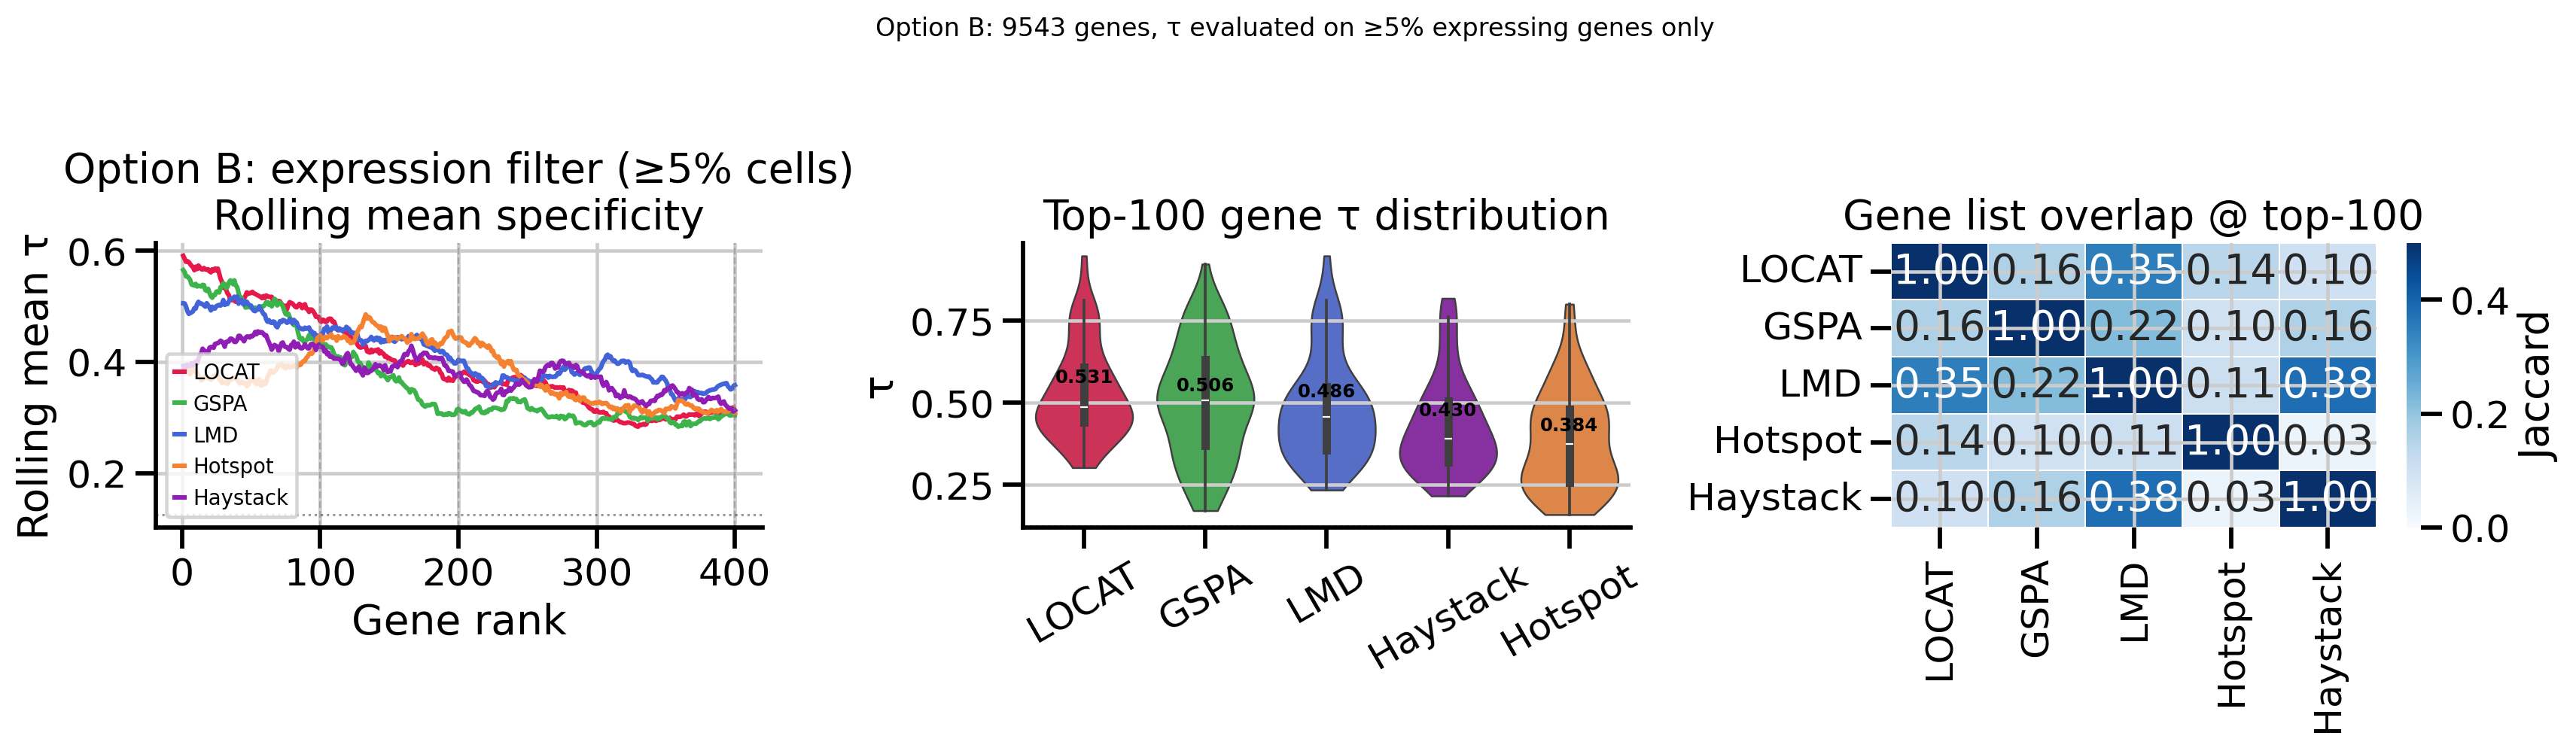


=== Option B summary ===


,Mean τ @ top-100,Mean τ @ top-200,Mean τ @ top-400,Frac τ>0.5 @ top-100,Frac τ>0.5 @ top-200,Frac τ>0.5 @ top-400
Method,,,,,,
GSPA,0.506,0.436,0.370,0.53,0.370,0.215
Haystack,0.430,0.415,0.383,0.28,0.275,0.208
Hotspot,0.384,0.414,0.380,0.23,0.275,0.205
LMD,0.486,0.464,0.417,0.40,0.345,0.238
LOCAT,0.531,0.475,0.401,0.47,0.355,0.205


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Rolling mean
ax = axes[0]
for method, ranked in method_rankings.items():
    ranked_v = [g for g in ranked if g in specificity_b.index and not np.isnan(specificity_b[g])]
    taus = np.array([specificity_b[g] for g in ranked_v[:MAX_RANK]])
    if len(taus) == 0: continue
    roll = pd.Series(taus).rolling(window=WINDOW, center=True, min_periods=1).mean().values
    ax.plot(np.arange(1, len(taus)+1), roll, label=method, color=colors[method], linewidth=2)
for c in CUTOFFS: ax.axvline(c, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(1/K, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.set_xlabel("Gene rank"); ax.set_ylabel("Rolling mean τ")
ax.set_title(f"Option B: expression filter (≥{EXPR_THRESH*100:.0f}% cells)\nRolling mean specificity")
ax.legend(fontsize=9); sns.despine(ax=ax)

# Violin
ax = axes[1]
vdata_b = []
for method, ranked in method_rankings.items():
    ranked_v = [g for g in ranked if g in specificity_b.index and not np.isnan(specificity_b[g])]
    for g in ranked_v[:100]: vdata_b.append({"Method": method, "tau": specificity_b[g]})
vdf_b = pd.DataFrame(vdata_b)
order_b = sorted(method_rankings.keys(), key=lambda m: -vdf_b[vdf_b.Method==m]["tau"].mean())
sns.violinplot(data=vdf_b, x="Method", y="tau", order=order_b,
               palette={m: colors[m] for m in order_b}, inner="box", cut=0, linewidth=0.8, ax=ax)
for i, m in enumerate(order_b):
    mv = vdf_b[vdf_b.Method==m]["tau"].mean()
    ax.text(i, mv+0.02, f"{mv:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.axhline(1/K, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.set_xlabel(""); ax.set_ylabel("τ"); ax.set_title("Top-100 gene τ distribution")
ax.tick_params(axis="x", rotation=30); sns.despine(ax=ax)

# Jaccard
ax = axes[2]
jac_b = pd.DataFrame(index=list(method_rankings.keys()), columns=list(method_rankings.keys()), dtype=float)
top_b_sets = {m: set([g for g in r if g in specificity_b.index and not np.isnan(specificity_b[g])][:100])
              for m, r in method_rankings.items()}
for m1 in jac_b.index:
    for m2 in jac_b.columns:
        s1, s2 = top_b_sets[m1], top_b_sets[m2]
        jac_b.loc[m1,m2] = len(s1&s2)/len(s1|s2) if len(s1|s2) else 0
sns.heatmap(jac_b.astype(float), annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=0.5, linewidths=0.5, ax=ax, cbar_kws={"label":"Jaccard"})
ax.set_title(f"Gene list overlap @ top-100")
plt.suptitle(f"Option B: 9543 genes, τ evaluated on ≥{EXPR_THRESH*100:.0f}% expressing genes only", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "optionB_exprfilter_comparison.svg", bbox_inches="tight")
plt.show()

# Summary
print("\n=== Option B summary ===")
rows_b = []
for method, ranked in method_rankings.items():
    rv = [g for g in ranked if g in specificity_b.index and not np.isnan(specificity_b[g])]
    for K_cut in CUTOFFS:
        t = [specificity_b[g] for g in rv[:K_cut]]
        rows_b.append({"Method":method,"Top-K":K_cut,"Mean τ":np.mean(t),"Frac τ>0.5":np.mean(np.array(t)>0.5)})
sumB = pd.DataFrame(rows_b).pivot(index="Method",columns="Top-K",values=["Mean τ","Frac τ>0.5"])
sumB.columns = [f"{v} @ top-{k}" for v,k in sumB.columns]
display(sumB.round(3))
sumB.to_csv(OUT_DIR / "specificity_summary_optionB.csv")

---
## Multi-seed analysis

PCA recomputed on HVGs with 8 different random seeds (run_multiseed.py). All methods use the same
recomputed X_pca per seed, so variation reflects sensitivity to the PCA embedding rather than
per-method internal randomness. GSPA additionally varies its own PHATE seed.

Results are in `scores/seed_{N}/`. Cells below aggregate across seeds and show mean ± stderr.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

SCORES_DIR = Path("scores")
CUTOFFS = [100, 200, 400]
THRESH = 0.5

# ── Reload full-gene adata for τ computation ──────────────────────────────────
adata_ms = sc.read_h5ad(DATA_PATH)
X_ms = adata_ms.X.toarray() if sp.issparse(adata_ms.X) else np.asarray(adata_ms.X)
pct_expr_ms = (X_ms > 0).mean(axis=0)
cell_types_ms = adata_ms.obs["louvain"].cat.categories.tolist()

mean_ms = np.array([X_ms[adata_ms.obs["louvain"] == ct].mean(axis=0) for ct in cell_types_ms])
rs_ms   = mean_ms.sum(axis=0)
expr_mask_ms = (rs_ms > 0) & (pct_expr_ms >= 0.05)   # Option B: ≥5% expressing
tau_b_arr_ms = np.where(expr_mask_ms, mean_ms.max(axis=0) / np.where(rs_ms > 0, rs_ms, 1), np.nan)
specificity_ms = pd.Series(tau_b_arr_ms, index=adata_ms.var_names)

def load_seed(seed_dir: Path):
    """Load all method rankings for one seed. Returns dict method -> ranked gene list."""
    d = {}
    # LOCAT
    f = seed_dir / "locat_scores.npz"
    if f.exists():
        x = np.load(f, allow_pickle=True)
        d["LOCAT"] = pd.Series(x["pval"], index=x["gene_names"]).sort_values().index.tolist()
    # GSPA
    f = seed_dir / "gspa_scores.npz"
    if f.exists():
        x = np.load(f, allow_pickle=True)
        d["GSPA"] = pd.Series(x["gene_localization"], index=x["var_names"]).sort_values(ascending=False).index.tolist()
    # LMD
    f = seed_dir / "lmd_scores.npz"
    if f.exists():
        x = np.load(f, allow_pickle=True)
        d["LMD"] = pd.Series(x["lmd_score"], index=x["var_names"]).sort_values(ascending=True).index.tolist()
    # Hotspot
    f = seed_dir / "hotspot_scores.npz"
    if f.exists():
        x = np.load(f, allow_pickle=True)
        d["Hotspot"] = pd.Series(x["fdr"], index=x["var_names"]).sort_values(ascending=True).index.tolist()
    # Haystack
    f = seed_dir / "haystack_scores.npz"
    if f.exists():
        x = np.load(f, allow_pickle=True)
        d["Haystack"] = pd.Series(x["logpval"], index=x["var_names"]).sort_values(ascending=True).index.tolist()
    return d

def tau_at_k(ranked, spec, k):
    valid = [g for g in ranked if g in spec.index and not np.isnan(spec[g])][:k]
    return np.mean([spec[g] for g in valid]) if valid else np.nan

def frac_above_at_k(ranked, spec, k, thresh=THRESH):
    valid = [g for g in ranked if g in spec.index and not np.isnan(spec[g])][:k]
    return np.mean([spec[g] > thresh for g in valid]) if valid else np.nan

# Collect results across seeds
seed_dirs = sorted(SCORES_DIR.glob("seed_*"))
print(f"Found {len(seed_dirs)} seed directories: {[s.name for s in seed_dirs]}")

records = []
for sd in seed_dirs:
    seed_id = sd.name
    rankings = load_seed(sd)
    for method, ranked in rankings.items():
        for k in CUTOFFS:
            records.append({
                "seed": seed_id,
                "method": method,
                "k": k,
                "mean_tau": tau_at_k(ranked, specificity_ms, k),
                "frac_above": frac_above_at_k(ranked, specificity_ms, k),
            })

df_ms = pd.DataFrame(records)
print(f"Loaded {len(df_ms)} records across {df_ms['seed'].nunique()} seeds, "
      f"{df_ms['method'].nunique()} methods")
print(df_ms.groupby(["method", "k"])["mean_tau"].agg(["mean", "sem"]).round(3).to_string())


In [ ]:
colors = {
    "LOCAT":    "#e6194b",
    "GSPA":     "#3cb44b",
    "LMD":      "#4363d8",
    "Hotspot":  "#f58231",
    "Haystack": "#911eb4",
}

fig, axes = plt.subplots(1, len(CUTOFFS), figsize=(5 * len(CUTOFFS), 5), sharey=False)

for ax, k in zip(axes, CUTOFFS):
    sub = df_ms[df_ms["k"] == k]
    agg = sub.groupby("method")["mean_tau"].agg(["mean", "sem"]).reset_index()
    agg = agg.sort_values("mean", ascending=False)

    bar_colors = [colors.get(m, "gray") for m in agg["method"]]
    bars = ax.bar(agg["method"], agg["mean"], color=bar_colors,
                  edgecolor="white", linewidth=0.5, zorder=2)
    ax.errorbar(range(len(agg)), agg["mean"], yerr=agg["sem"] * 1.96,
                fmt="none", color="black", capsize=4, linewidth=1.5, zorder=3)

    # overlay individual seed points
    for i, method in enumerate(agg["method"]):
        pts = sub[sub["method"] == method]["mean_tau"].values
        ax.scatter(np.full(len(pts), i) + np.random.uniform(-0.15, 0.15, len(pts)),
                   pts, color="black", s=18, alpha=0.5, zorder=4)

    ax.set_title(f"Top-{k} genes")
    ax.set_ylabel("Mean τ (Option B: ≥5% expressed)" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)
    for bar, row in zip(bars, agg.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, row.mean + row.sem * 1.96 + 0.005,
                f"{row.mean:.3f}", ha="center", va="bottom", fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(
    f"Multi-seed comparison (n={df_ms['seed'].nunique()} seeds)\n"
    "Mean τ ± 95% CI, Option B (≥5% expressing genes)",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.savefig(OUT_DIR / "multiseed_mean_tau.svg", bbox_inches="tight")
plt.show()

# Summary table
print("\n=== Multi-seed summary (mean ± sem) ===")
for k in CUTOFFS:
    sub = df_ms[df_ms["k"] == k]
    agg = sub.groupby("method")["mean_tau"].agg(["mean", "sem"]).sort_values("mean", ascending=False)
    agg.columns = [f"Mean τ", "SEM"]
    print(f"\nTop-{k}:")
    print(agg.round(4).to_string())
